## [Experiment #2] Sample notebook to simualate augmentation and dataloaders / dataset preparations

#### [Exp 1]: Augmentation simulation

In [6]:
%reload_ext autoreload
%autoreload 2

import sys, os
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.preprocessing import (
    preprocess_image_retina,
    preprocess_mask,
    derive_fov_mask_path_from_image,
)
from src.data.augmentations import get_train_augs

# ---- Config ----
TARGET = 512
SEED = 1337  # set to None for different results each run

def _overlay(img_hw: np.ndarray, msk_hw: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    img_rgb = np.stack([img_hw, img_hw, img_hw], axis=-1)
    red = np.zeros_like(img_rgb); red[..., 0] = 1.0
    overlay = (1 - alpha) * img_rgb + alpha * (red * msk_hw[..., None])
    return np.clip(overlay, 0.0, 1.0)

def visualize_augmentations(
    image_path: str,
    label_path: str,
    n_samples: int = 6,
    apply_fov_after: bool = True,
    gamma: float = 0.9,
    clahe_clip: float = 2.0,
    clahe_tiles: int = 8,
):
    # ---- deterministic randomness (optional) ----
    if SEED is not None:
        import random
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)

    # ---- preprocess WITHOUT applying FOV inside (we'll gate after) ----
    img = preprocess_image_retina(
        image_path, target_size=TARGET, use_gamma=True, gamma=gamma,
        clahe_clip=clahe_clip, clahe_tiles=clahe_tiles,
        apply_fov=False, mask_path=None, auto_discover_mask=False,
    )[0]  # (H,W)

    msk = preprocess_mask(label_path, target_size=TARGET)[0]  # (H,W) {0,1}

    if apply_fov_after:
        fov_path = derive_fov_mask_path_from_image(image_path)
        fov = preprocess_mask(fov_path, target_size=TARGET)[0]
        img = (img * fov).astype(np.float32)

    augs = get_train_augs(size=TARGET)

    cols = n_samples + 1
    fig, axes = plt.subplots(3, cols, figsize=(3.4*cols, 9))
    if cols == 1: axes = np.asarray(axes).reshape(3,1)

    axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=1);  axes[0, 0].set_title("Baseline Image", fontsize=10)
    axes[1, 0].imshow(msk, cmap="gray", vmin=0, vmax=1);  axes[1, 0].set_title("Baseline Mask", fontsize=10)
    axes[2, 0].imshow(_overlay(img, msk));                 axes[2, 0].set_title("Baseline Overlay", fontsize=10)
    for r in range(3): axes[r, 0].axis("off")

    for j in range(1, cols):
        out = augs(image=img, mask=msk)
        img_t, msk_t = out["image"], out["mask"]
        if msk_t.ndim == 3: msk_t = msk_t[0]
        img_aug = img_t[0].cpu().numpy()
        msk_aug = (msk_t.cpu().numpy() > 0.5).astype(np.float32)

        axes[0, j].imshow(img_aug, cmap="gray", vmin=0, vmax=1); axes[0, j].set_title(f"Aug #{j} — Image", fontsize=10)
        axes[1, j].imshow(msk_aug, cmap="gray", vmin=0, vmax=1); axes[1, j].set_title(f"Aug #{j} — Mask", fontsize=10)
        axes[2, j].imshow(_overlay(img_aug, msk_aug));           axes[2, j].set_title(f"Aug #{j} — Overlay", fontsize=10)
        for r in range(3): axes[r, j].axis("off")

    plt.tight_layout(); plt.show()


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\..\src\data\augmentations.py:52: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 15.0)),    # adds Gaussian sensor noise, variance between 5–15


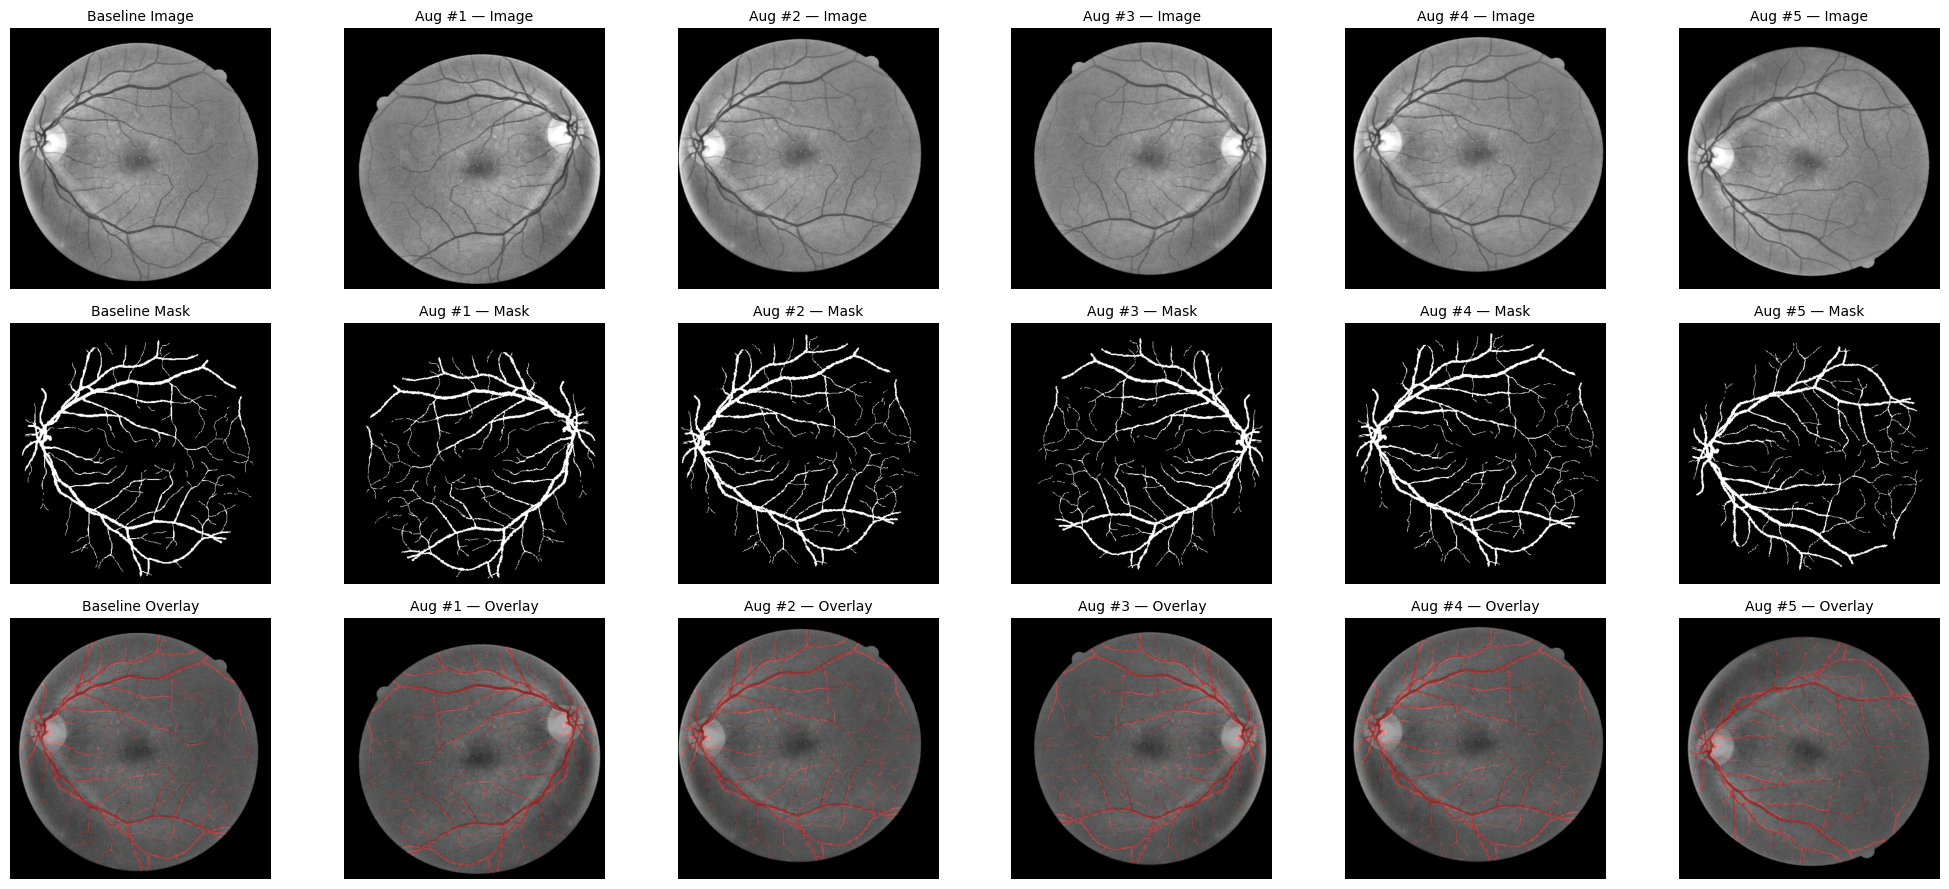

In [9]:
# Pick one image + its manual GT
img_path = "../data/raw/DRIVE/training/images/21_training.png"
lab_path = "../data/raw/DRIVE/training/1st_manual/21_manual1.png"

visualize_augmentations(
    image_path=img_path,
    label_path=lab_path,
    n_samples=5,          # how many randomized augs to show
    apply_fov_after=True, # multiply FOV after preprocessing (your strict preproc is happy)
    gamma=0.9,
    clahe_clip=2.0,
    clahe_tiles=8,
)
